In [4]:
# Imports and Load Data
import pandas as pd
import matplotlib.pyplot as plt

# Load the main dataset ( hourly citylevel data)
df = pd.read_csv('../data/raw/city_hour.csv')

print(f"Dataset Loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")     # How many features
print(f"Memory usage: {df.memory_usage().sum() / 1024**2:.1f} MB")


Dataset Loaded successfully!
Rows: 707,875
Columns: 16
Memory usage: 86.4 MB


In [5]:
df.head(5)

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.0,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.0,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.0,0.0,NaN,NaN
3,Ahmedabad,2015-01-01 04:00:00,NaN,NaN,0.30,16.45,9.20,NaN,0.30,39.53,153.58,0.0,0.0,0.0,NaN,NaN
4,Ahmedabad,2015-01-01 05:00:00,NaN,NaN,0.12,14.90,7.85,NaN,0.12,32.63,NaN,0.0,0.0,0.0,NaN,NaN


In [10]:
print("=== Data Types ===")
print(df.dtypes)
print(f"\n=== Quick Summary ===")
df.info()

=== Data Types ===
City              str
Datetime          str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

=== Quick Summary ===
<class 'pandas.DataFrame'>
RangeIndex: 707875 entries, 0 to 707874
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   City        707875 non-null  str    
 1   Datetime    707875 non-null  str    
 2   PM2.5       562787 non-null  float64
 3   PM10        411138 non-null  float64
 4   NO          591243 non-null  float64
 5   NO2         590753 non-null  float64
 6   NOx         584651 non-null  float64
 7   NH3         435333 non-null  float64
 8   CO          621358 non-null  float64
 9   SO2         577502 non-nu

In [11]:
df.shape

(707875, 16)

In [8]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,562787.000000,411138.000000,591243.000000,590753.000000,584651.000000,435333.000000,621358.000000,577502.000000,578667.000000,544229.000000,487268.000000,252046.000000,578795.000000
mean,67.622994,119.075804,17.421755,28.885157,32.287565,23.607959,2.183539,14.038307,34.798979,3.087595,8.660927,3.130537,166.413500
std,74.730496,104.224752,32.095211,29.162194,39.756669,28.831900,10.970514,19.305540,29.806379,16.456599,21.741023,7.834832,162.112729
min,0.010000,0.010000,0.010000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,8.000000
25%,26.200000,52.380000,3.840000,10.810000,10.660000,8.120000,0.420000,4.880000,13.420000,0.050000,0.370000,0.100000,79.000000
50%,46.420000,91.500000,7.960000,20.320000,20.790000,15.380000,0.800000,8.370000,26.240000,0.860000,2.590000,0.790000,116.000000
75%,79.490000,147.520000,16.150000,36.350000,37.150000,29.230000,1.370000,14.780000,47.620000,2.750000,8.410000,3.120000,208.000000
max,999.990000,1000.000000,499.990000,499.510000,498.610000,499.970000,498.570000,199.960000,497.620000,498.070000,499.400000,499.990000,3133.000000


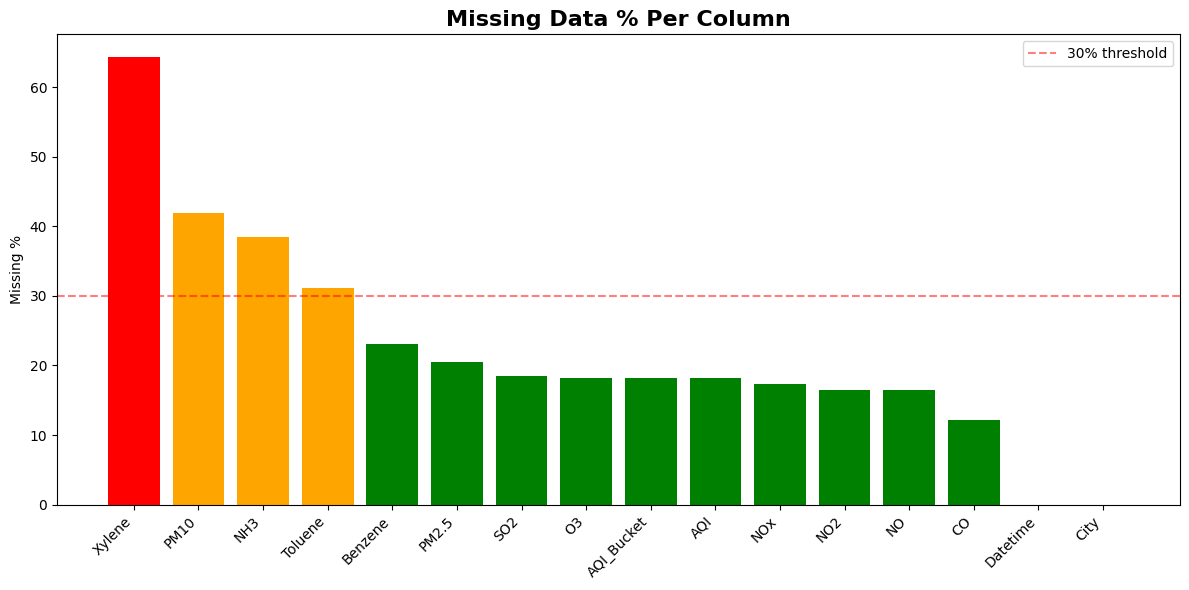

🔴 Red = >50% missing (drop column)
🟠 Orange = 30-50% missing (handle carefully)
🟢 Green = <30% missing (good to use)


In [9]:
# Cell 4: Visualize missing values
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(missing_pct.index, missing_pct.values, color=['red' if x > 50 else 'orange' if x > 30 else 'green' for x in missing_pct.values])
plt.title('Missing Data % Per Column', fontsize=16, fontweight='bold')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=30, color='red', linestyle='--', alpha=0.5, label='30% threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("🔴 Red = >50% missing (drop column)")
print("🟠 Orange = 30-50% missing (handle carefully)")
print("🟢 Green = <30% missing (good to use)")


In [12]:
# Cell 5: Which cities and how much data each?
city_counts = df['City'].value_counts()

print(f"Total unique cities: {len(city_counts)}\n")
print("Rows per city:")
print(city_counts.to_string())


Total unique cities: 26

Rows per city:
City
Ahmedabad             48192
Bengaluru             48192
Chennai               48192
Delhi                 48192
Lucknow               48192
Mumbai                48192
Hyderabad             48107
Patna                 44554
Gurugram              40258
Visakhapatnam         35053
Amritsar              29269
Jorapokhar            28025
Jaipur                26705
Thiruvananthapuram    26651
Amaravati             22784
Brajrajnagar          22468
Talcher               22161
Kolkata               19503
Guwahati              12002
Coimbatore             9229
Shillong               7402
Chandigarh             7263
Bhopal                 6903
Kochi                  3854
Ernakulam              3852
Aizawl                 2680


In [15]:
df.shape

(707875, 16)

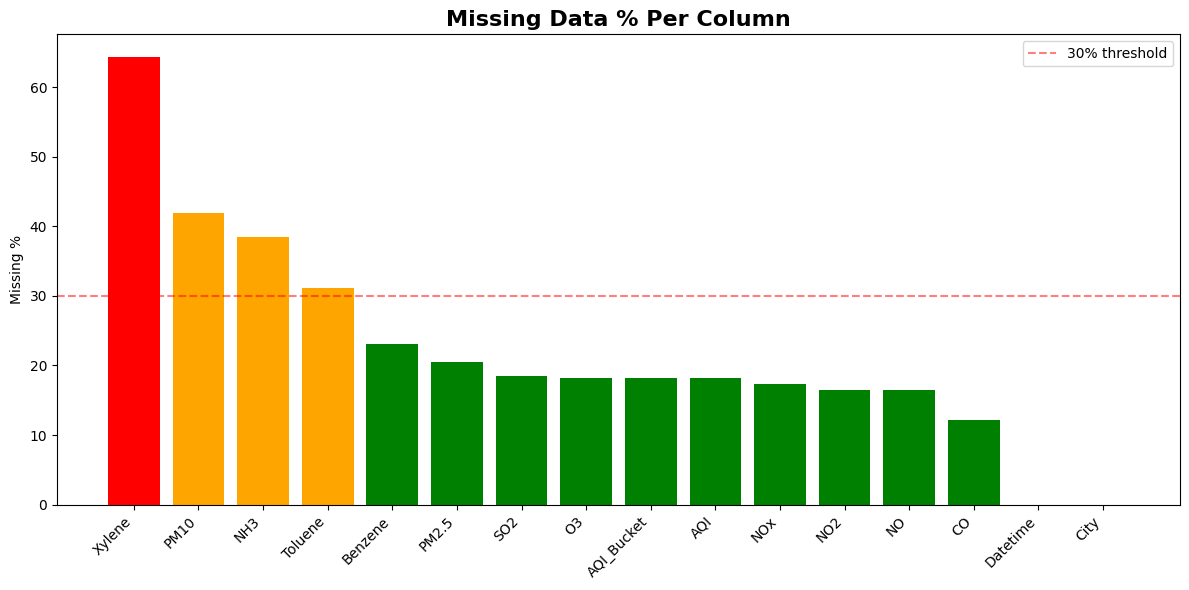

In [30]:
# Cell 4: Visualize missing values
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(missing_pct.index, missing_pct.values, color=['red' if x > 50 else 'orange' if x > 30 else 'green' for x in missing_pct.values])
plt.title('Missing Data % Per Column', fontsize=16, fontweight='bold')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=30, color='red', linestyle='--', alpha=0.5, label='30% threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Cell 6: Convert Datetime from string to proper datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])

print(f"Date range: {df['Datetime'].min()} to {df['Datetime'].max()}")
print(f"Total duration: {df['Datetime'].max() - df['Datetime'].min()}")
print(f"\nData per year:")
print(df['Datetime'].dt.year.value_counts().sort_index())


Date range: 2015-01-01 01:00:00 to 2020-07-01 00:00:00
Total duration: 2007 days 23:00:00

Data per year:
Datetime
2015     67174
2016     83460
2017    112440
2018    155294
2019    178634
2020    110873
Name: count, dtype: int64


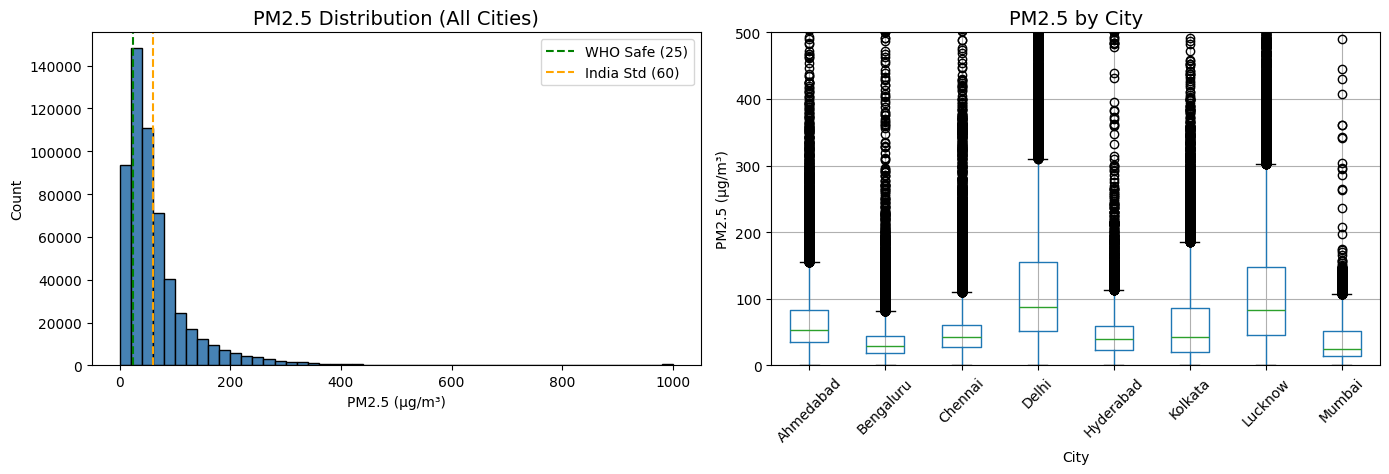

In [36]:
# Cell 7: PM2.5 distribution — how is pollution spread?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — shows frequency of each PM2.5 range
axes[0].hist(df['PM2.5'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('PM2.5 Distribution (All Cities)', fontsize=14)
axes[0].set_xlabel('PM2.5 (μg/m³)')
axes[0].set_ylabel('Count')
axes[0].axvline(x=25, color='green', linestyle='--', label='WHO Safe (25)')
axes[0].axvline(x=60, color='orange', linestyle='--', label='India Std (60)')
axes[0].legend()

# Boxplot per city — shows median, range, outliers
top_cities = ['Delhi', 'Mumbai', 'Bengaluru', 'Kolkata', 'Chennai', 'Hyderabad', 'Ahmedabad', 'Lucknow']
city_data = df[df['City'].isin(top_cities)]
city_data.boxplot(column='PM2.5', by='City', ax=axes[1], rot=45)
axes[1].set_title('PM2.5 by City', fontsize=14)
axes[1].set_ylabel('PM2.5 (μg/m³)')
axes[1].set_ylim(0, 500)  # Cap at 500 to see the pattern clearly
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()


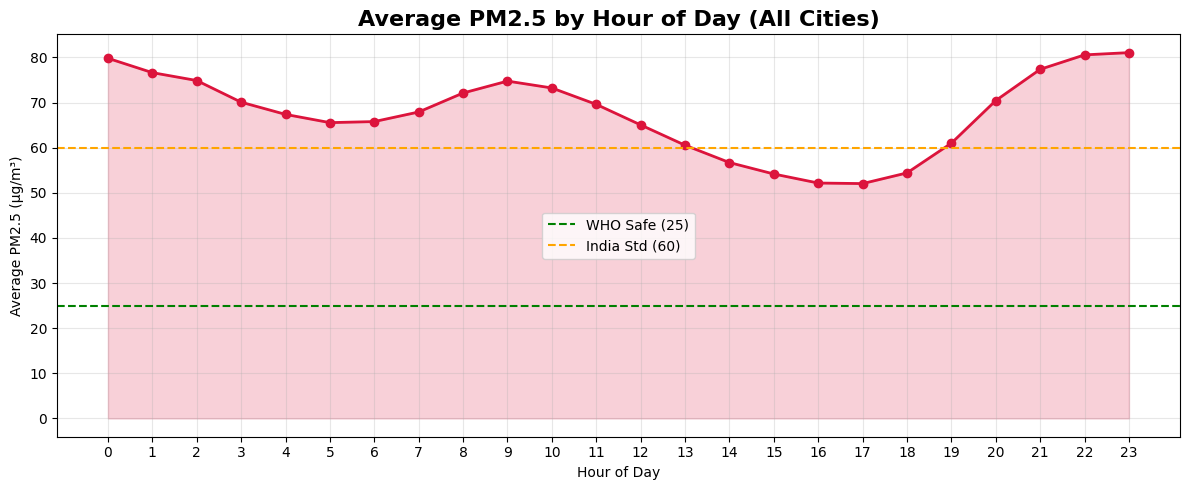

Peak pollution hours are highlighted above.
This pattern tells us WHEN in the day air is worst.


In [37]:
# Cell 8: Hourly pollution pattern — when is air worst during the day?
df['Hour'] = df['Datetime'].dt.hour

hourly_avg = df.groupby('Hour')['PM2.5'].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='crimson', linewidth=2)
plt.fill_between(hourly_avg.index, hourly_avg.values, alpha=0.2, color='crimson')
plt.title('Average PM2.5 by Hour of Day (All Cities)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average PM2.5 (μg/m³)')
plt.xticks(range(0, 24))
plt.axhline(y=25, color='green', linestyle='--', label='WHO Safe (25)')
plt.axhline(y=60, color='orange', linestyle='--', label='India Std (60)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Peak pollution hours are highlighted above.")
print("This pattern tells us WHEN in the day air is worst.")


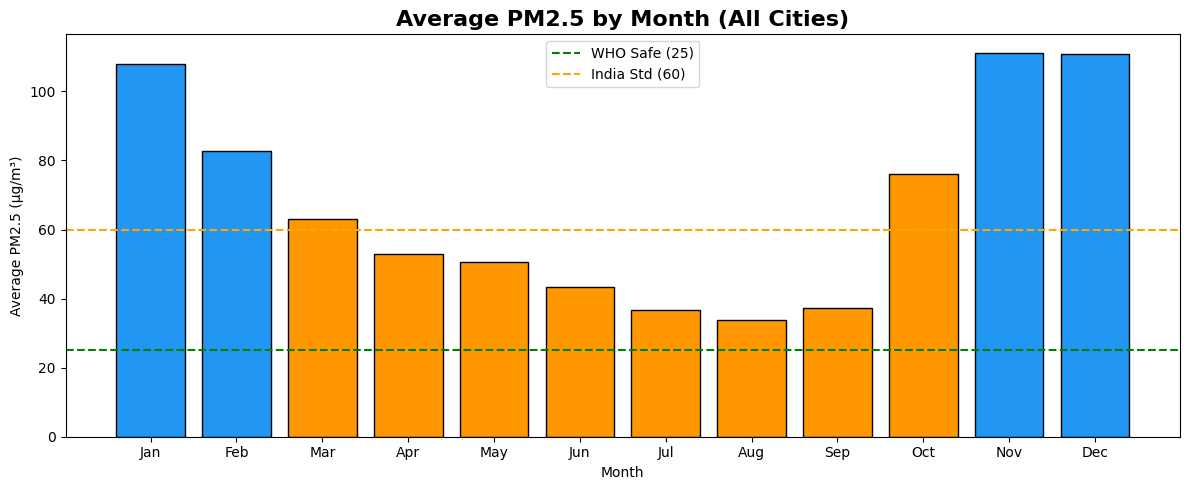

🔵 Blue = Winter months (Nov-Feb, worst pollution)
🟠 Orange = Other months
Notice the HUGE difference between winter and summer!


In [38]:
# Cell 9: Monthly pollution — winter vs summer
df['Month'] = df['Datetime'].dt.month

monthly_avg = df.groupby('Month')['PM2.5'].mean()

plt.figure(figsize=(12, 5))
bars = plt.bar(monthly_avg.index, monthly_avg.values, 
               color=['#2196F3' if m in [11,12,1,2] else '#FF9800' for m in monthly_avg.index],
               edgecolor='black')
plt.title('Average PM2.5 by Month (All Cities)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average PM2.5 (μg/m³)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.axhline(y=25, color='green', linestyle='--', label='WHO Safe (25)')
plt.axhline(y=60, color='orange', linestyle='--', label='India Std (60)')
plt.legend()
plt.tight_layout()
plt.show()

print("🔵 Blue = Winter months (Nov-Feb, worst pollution)")
print("🟠 Orange = Other months")
print("Notice the HUGE difference between winter and summer!")


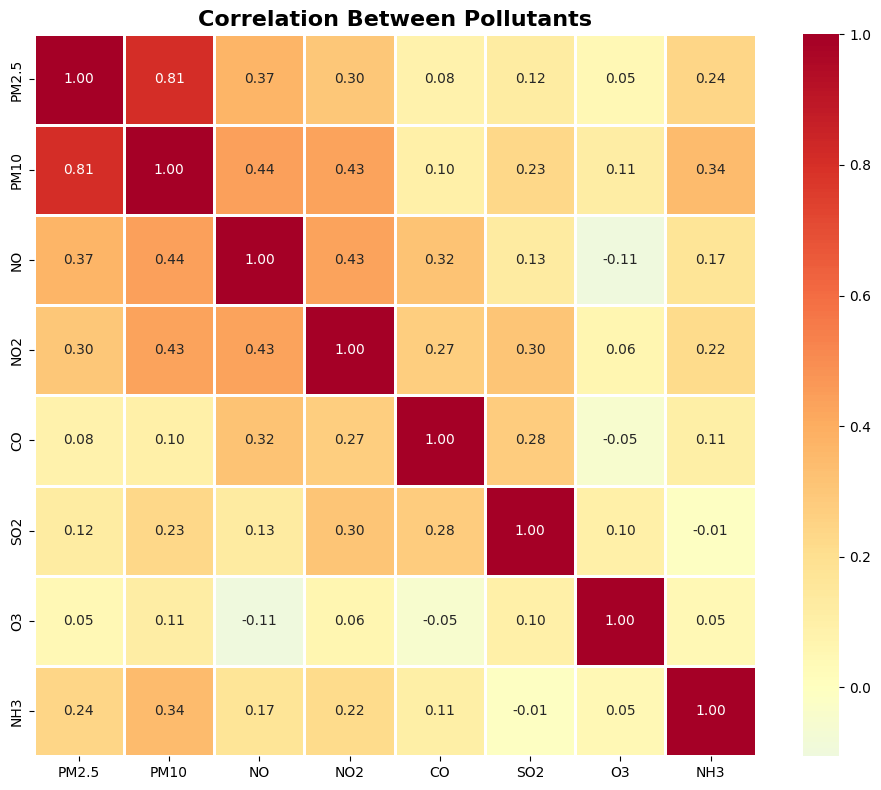


Values close to +1.0 = move together (positive correlation)
Values close to -1.0 = move opposite (negative correlation)
Values close to  0.0 = no relationship


In [40]:
# Cell 10: Correlation heatmap — which pollutants move together?
import seaborn as sns

# Select only the pollutant columns we care about
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'CO', 'SO2', 'O3', 'NH3']
corr_matrix = df[pollutant_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Between Pollutants', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nValues close to +1.0 = move together (positive correlation)")
print("Values close to -1.0 = move opposite (negative correlation)")
print("Values close to  0.0 = no relationship")
